#### Exact Matching  Evaluierung

In [9]:
import re
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter
from latex_functions_p1 import *
from evaluate_functions_p1 import *
from plot_functions_p1 import *

### Wähle den evaluations Ordner

In [2]:
versuch_ordner = "eval_p1_models_prompt6_evaldata/" 
versuch_name = "models"

label_folder = '../input/lct_p1'
raw_lct_text_folder = '../input/lct_txt'
model_output_folder = versuch_ordner + 'model_output'

models = [folder for folder in os.listdir(model_output_folder) if os.path.isdir(os.path.join(model_output_folder, folder))]

models

['Claude-3.5-Sonnet_10_shot_temp_0.5',
 'Gemma-27b_5_shot',
 'Llama-2-70B_3_shot',
 'Llama-3-8B-Instruct_5_shot',
 'Llama3-70b_5_shot',
 'Qwen2-72B_15_shot']

In [3]:
all_metrics = {}
for model in models:
    model_folder = os.path.join(model_output_folder, model, 'output')
    metrics = evaluate_models(label_folder, model_folder, model, raw_lct_text_folder)
    all_metrics[model] = metrics

### Missing Words PCT

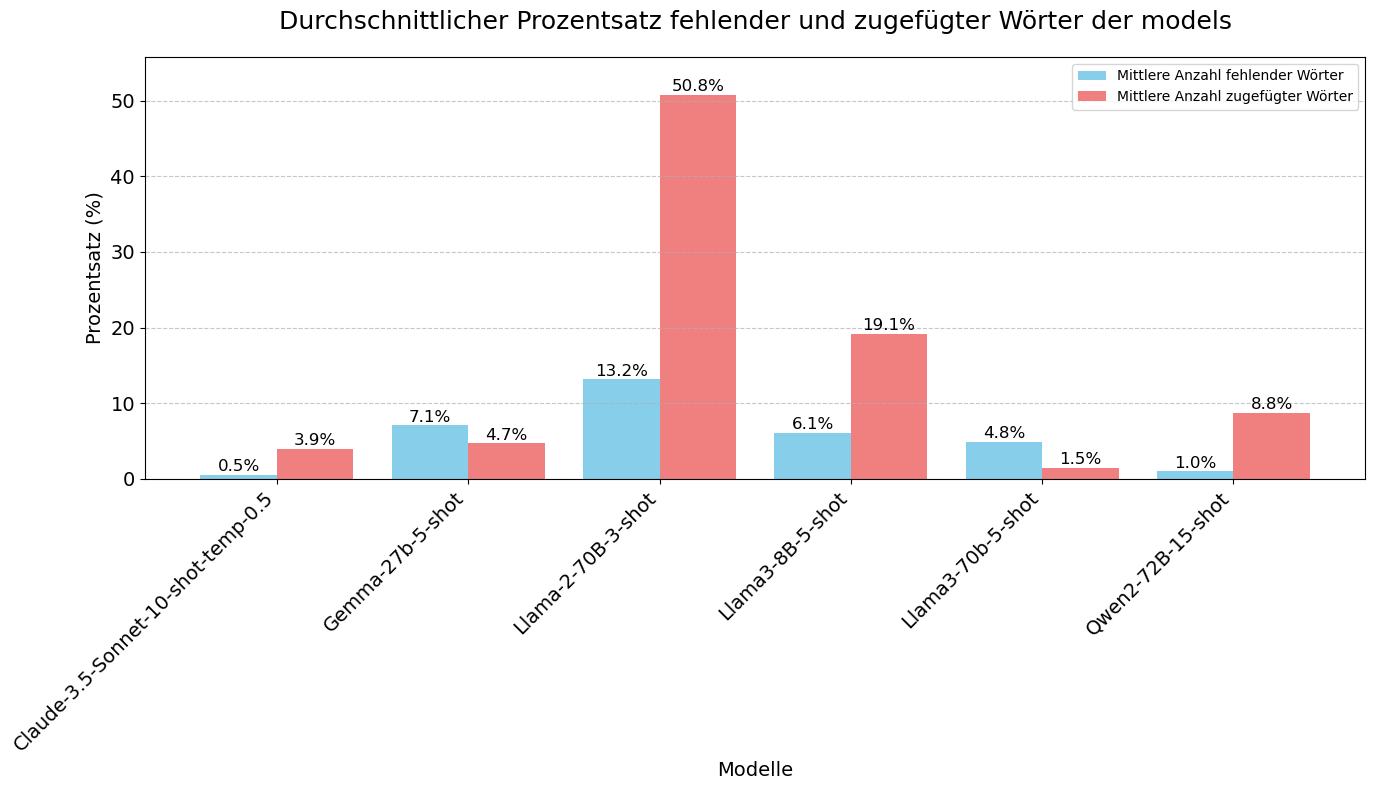

In [5]:
plot_avg_pct(all_metrics, versuch_name)

In [6]:
def calculate_mean_excel(data, model_names, file_path='excel/n_shot_mean_results.xlsx'):
    n_shot_models = [model for model in data.keys() if model.startswith(model_names)]
    precisions = []
    recalls = []
    f1_scores = []
    missing_percentages = []
    excess_percentages = []

    for model in n_shot_models:
        print(model)
        avg = data[model]['average']
        precisions.append(avg['precision'])
        recalls.append(avg['recall'])
        f1_scores.append(avg['f1'])
        missing_percentages.append(data[model]['average_missing_percentage'])
        excess_percentages.append(data[model]['average_zuviel_percentage'])

    avg_precision = np.mean(precisions)
    avg_recall = np.mean(recalls)
    avg_f1 = np.mean(f1_scores)
    avg_missing_percentage = np.mean(missing_percentages)
    avg_excess_percentage = np.mean(excess_percentages)
    print(avg_missing_percentage)
    std_precision = np.std(precisions)
    std_recall = np.std(recalls)
    std_f1 = np.std(f1_scores)
    std_missing_percentage = np.std(missing_percentages)
    std_excess_percentage = np.std(excess_percentages)

    result = {
        'average_precision': avg_precision,
        'average_recall': avg_recall,
        'average_f1': avg_f1,
        'std_precision': std_precision,
        'std_recall': std_recall,
        'std_f1': std_f1,
        'average_missing_percentage': avg_missing_percentage,
        'average_excess_percentage': avg_excess_percentage,
        'std_missing_percentage': std_missing_percentage,
        'std_excess_percentage': std_excess_percentage
    }

    df = pd.DataFrame(result, index=[model_names])
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    if os.path.exists(file_path):
        existing_df = pd.read_excel(file_path, index_col=0)
        existing_df.update(df)
        df = pd.concat([existing_df, df[~df.index.isin(existing_df.index)]])

    df.to_excel(file_path)
    print(f"Results saved/updated in {file_path}")

    return result

In [7]:
#calculate_mean_excel(all_metrics, model_names="3_shot")

### Durchschnittliche Performance über alle Operatoren [AND, OR, NOT] 

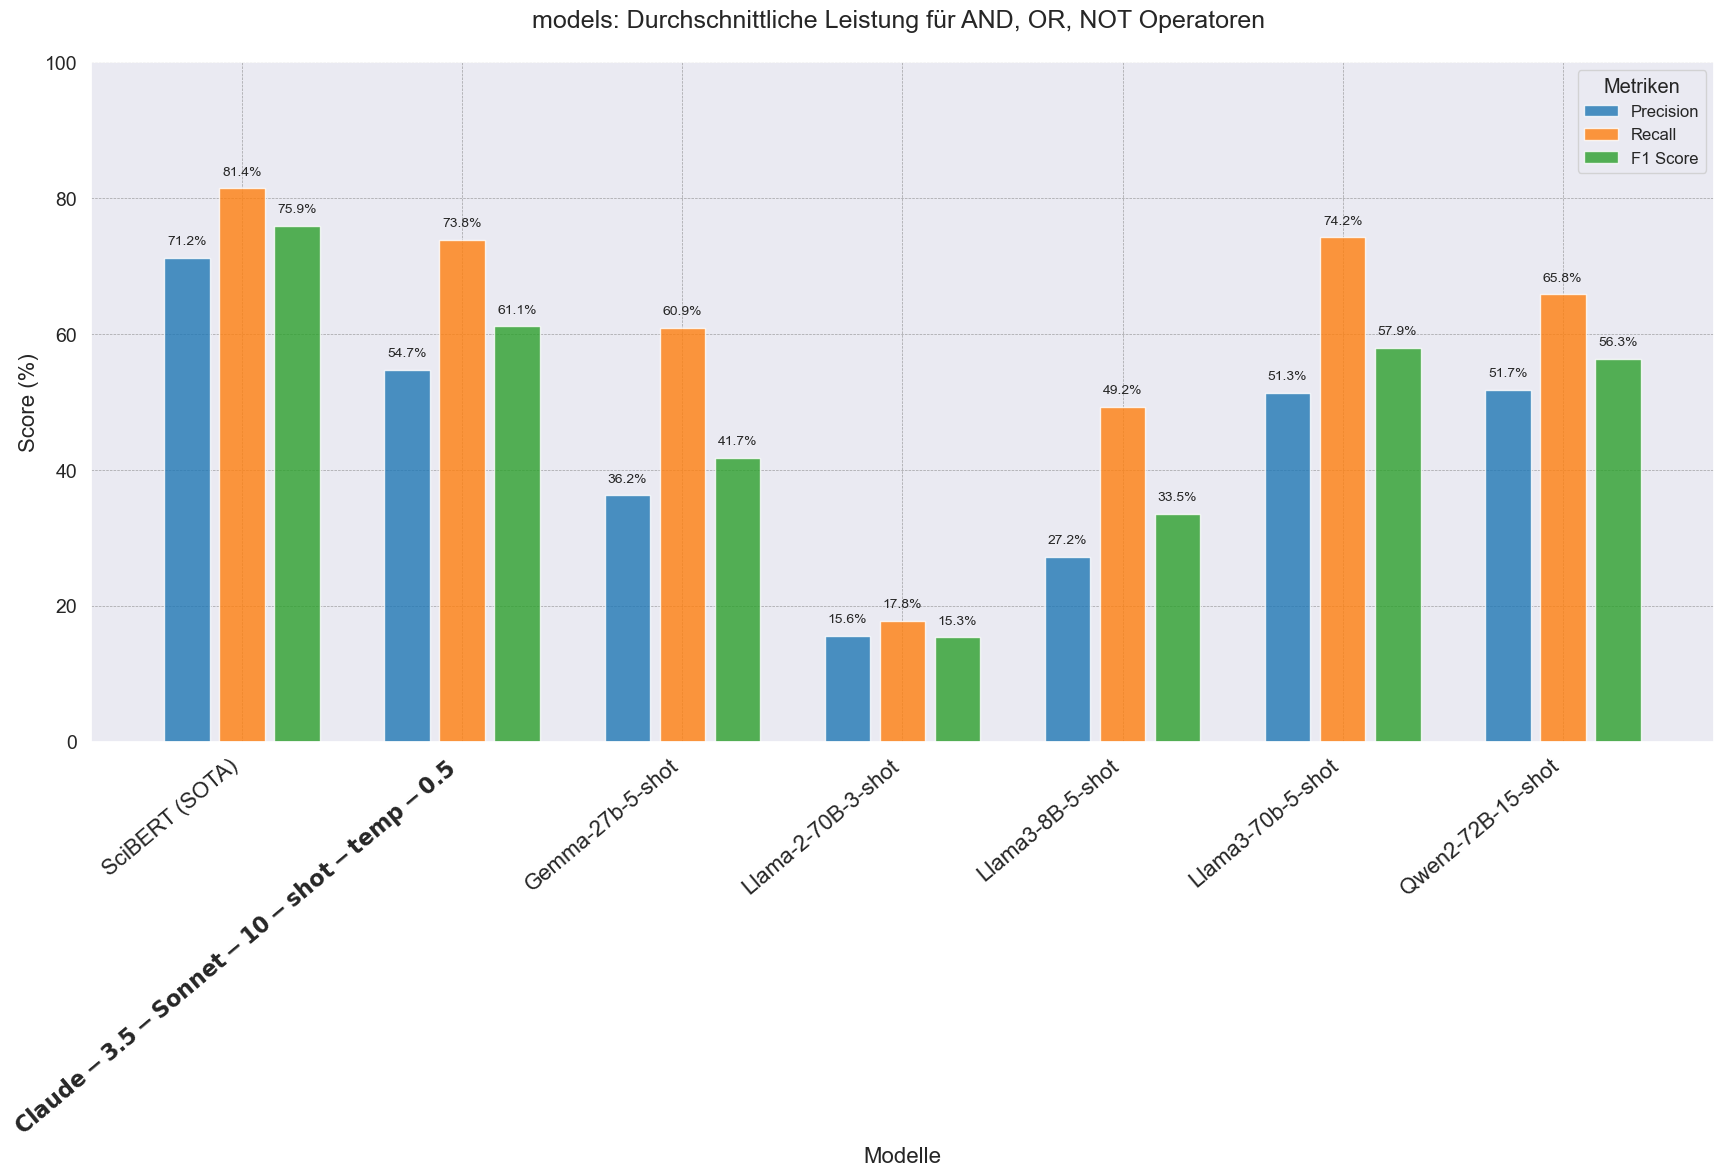

In [8]:
plot_avg_metrics(all_metrics, versuch_name)

### Durchschnittliche Performance über alle Operatoren [AND, OR, NOT] to LATEX

In [ ]:
avg_operators_latex(all_metrics, versuch_name)

### Perfomance der einzelnen Operatoren

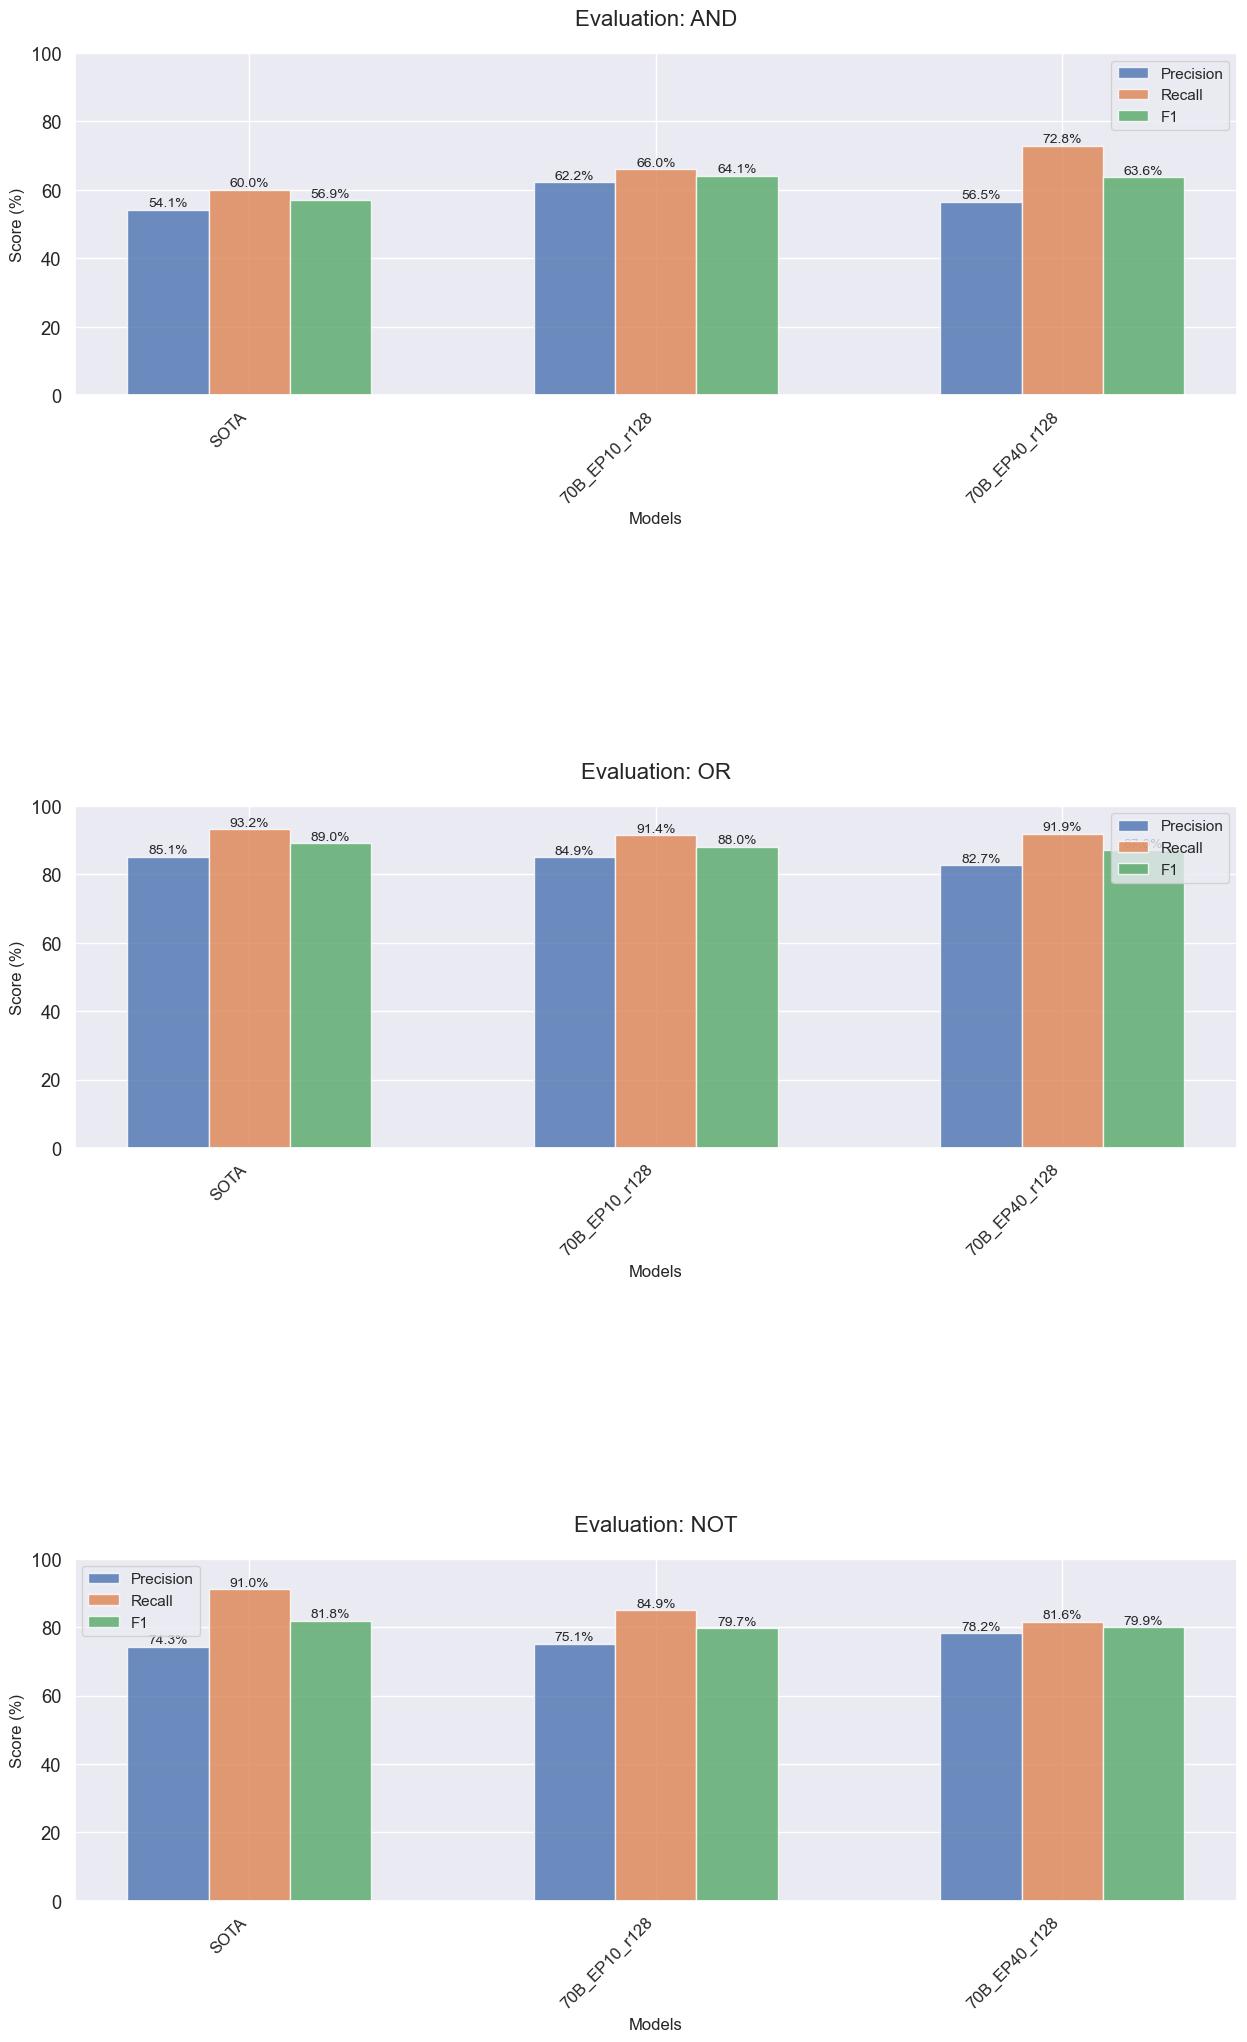

In [161]:
plot_metrics(all_metrics)

### Plot Anzahl Operators

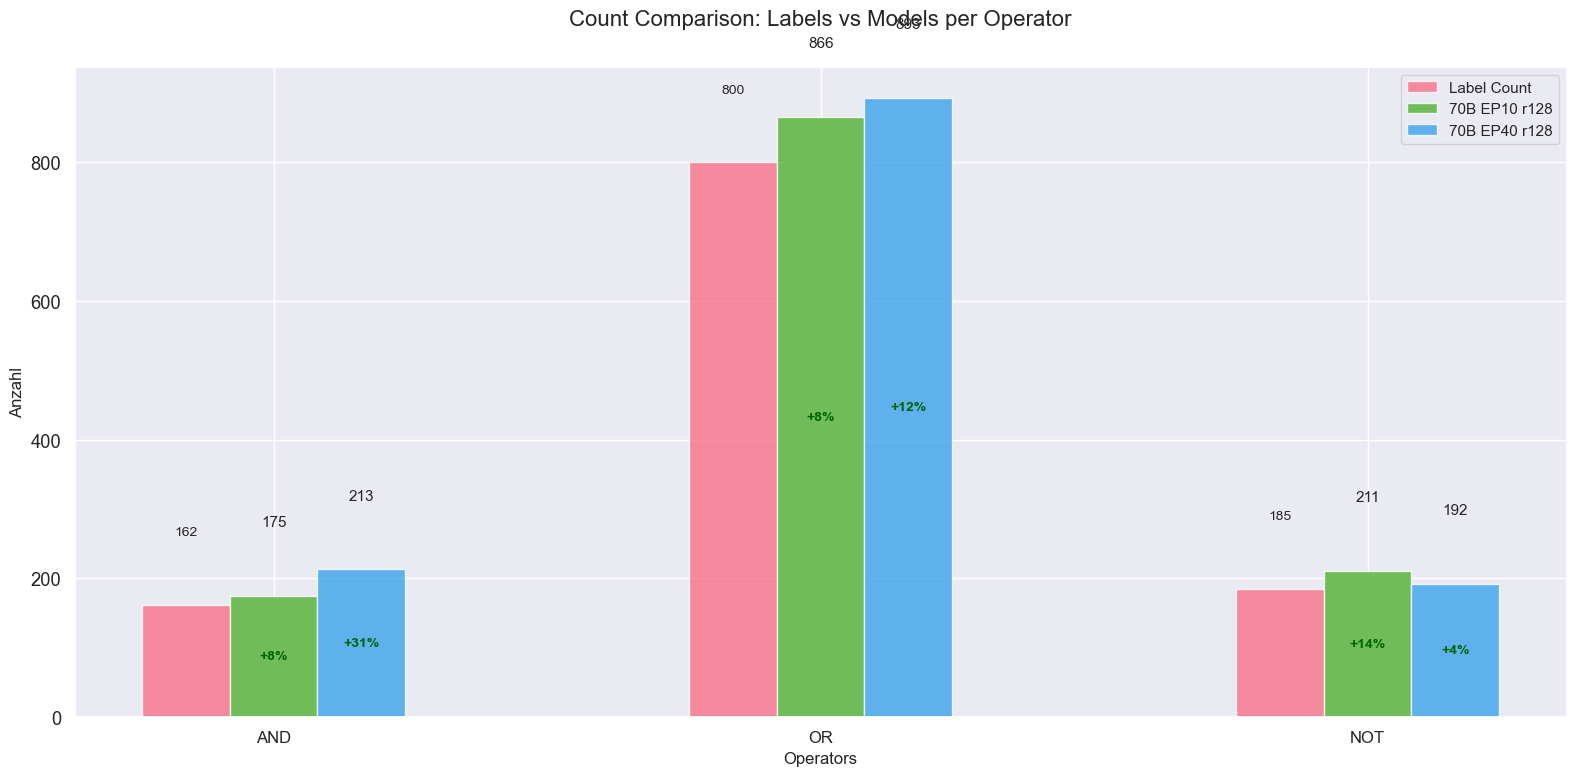

In [163]:
plot_count_comparison(all_metrics)

### Evaluiere n-shot Modelle

## Model vs SOTA


In [10]:
print(models)

model_to_plot = models[len(models)-2] # len(models)-1
model_name = model_to_plot
model_to_plot

['Claude-3.5-Sonnet_10_shot_temp_0.5', 'Gemma-27b_5_shot', 'Llama-2-70B_3_shot', 'Llama-3-8B-Instruct_5_shot', 'Llama3-70b_5_shot', 'Qwen2-72B_15_shot']


'Llama3-70b_5_shot'

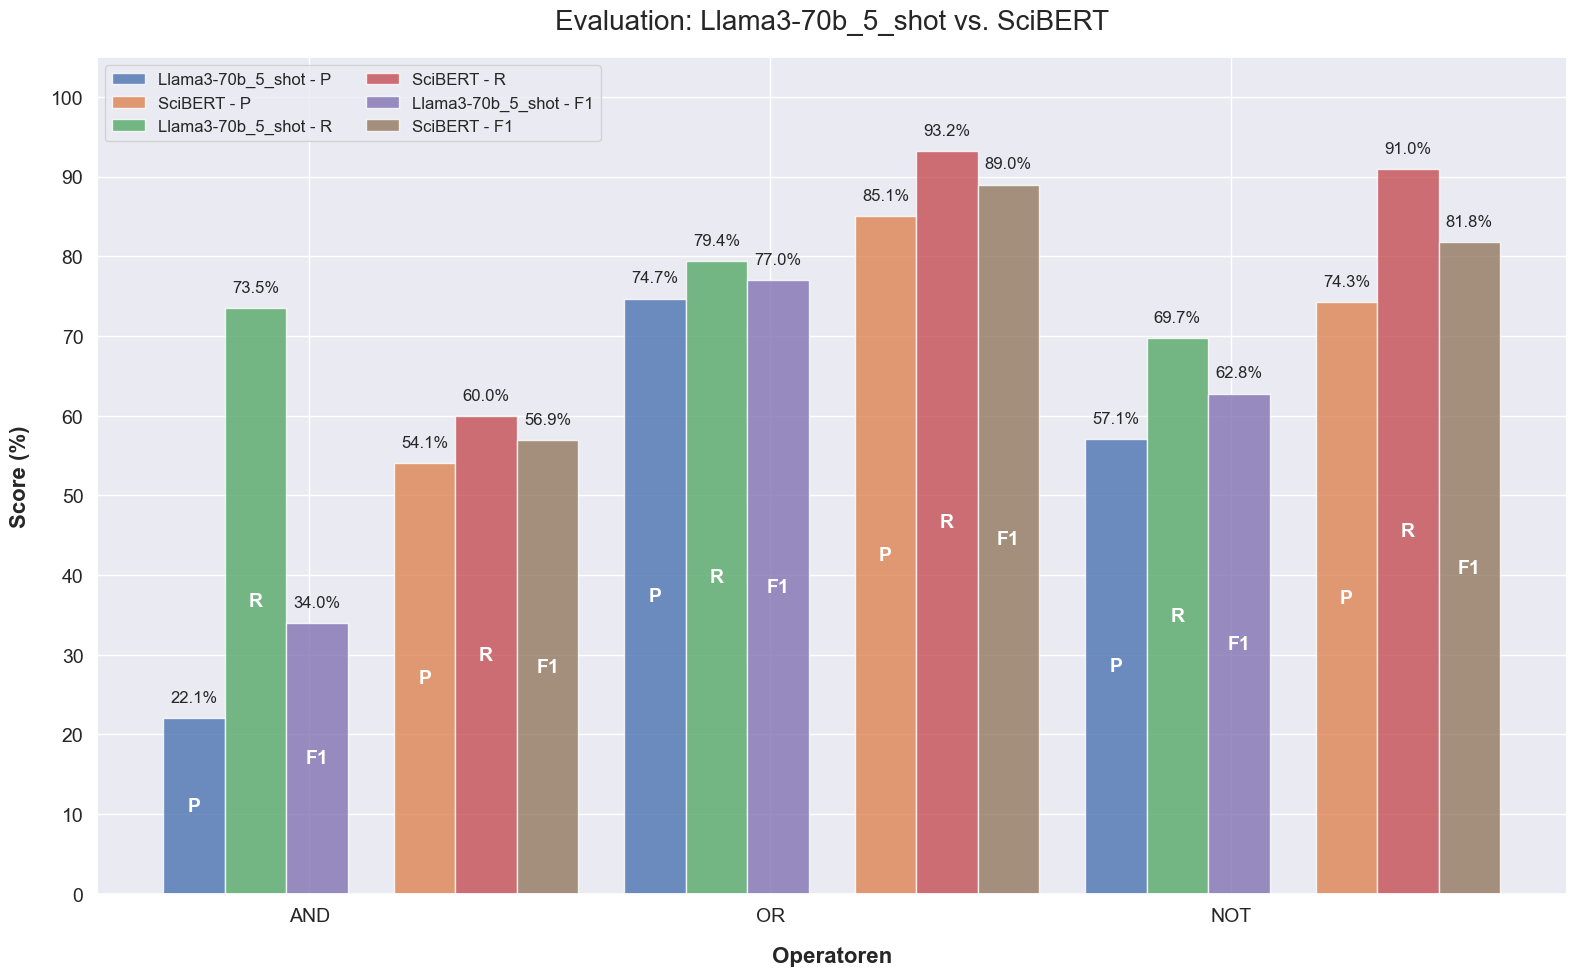

In [11]:
model_metrics = all_metrics[model_to_plot]


sota_metrics = {
    'SciBERT': {
        'AND': {'precision': 54.1, 'recall': 60.0, 'f1': 56.9},
        'NOT': {'precision': 74.3, 'recall': 91.0, 'f1': 81.8},
        'OR': {'precision': 85.1, 'recall': 93.2, 'f1': 89.0},
        'average': {'precision': 71.16, 'recall': 81.39, 'f1': 75.89}
    },
    'R-BERT + SciBERT': {
        'AND': {'precision': 53.8, 'recall': 53.8, 'f1': 53.8},
        'NOT': {'precision': 74.5, 'recall': 88.7, 'f1': 81.0},
        'OR': {'precision': 88.4, 'recall': 92.2, 'f1': 90.2},
        'average': {'precision': 72.23, 'recall': 78.23, 'f1': 75.0}
    }
}

operators = ['AND', 'OR', 'NOT']
metrics_to_plot = ['precision', 'recall', 'f1']
metric_labels = {'precision': 'P', 'recall': 'R', 'f1': 'F1'}

fig, ax = plt.subplots(figsize=(16, 10))

x = np.arange(len(operators))
bar_width = 0.4
opacity = 0.8
gap = 0.1

for i, metric in enumerate(metrics_to_plot):
    model_values = [model_metrics[op][metric] for op in operators]
    sota_values = [sota_metrics['SciBERT'][op][metric] for op in operators]

    ax.bar(x - bar_width/2 - gap/2 + i*bar_width/3, model_values, bar_width/3, alpha=opacity, label=f'{model_name.split("-Instruct")[0]} - {metric_labels[metric]}')
    ax.bar(x + bar_width/2 + gap/2 + i*bar_width/3, sota_values, bar_width/3, alpha=opacity, label=f'SciBERT - {metric_labels[metric]}')

    for j, (model_value, sota_value) in enumerate(zip(model_values, sota_values)):
        ax.text(j - bar_width/2 - gap/2 + i*bar_width/3, model_value/2, f'{metric_labels[metric]}', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
        ax.text(j + bar_width/2 + gap/2 + i*bar_width/3, sota_value/2, f'{metric_labels[metric]}', ha='center', va='center', fontsize=14, fontweight='bold', color='white')

        ax.text(j - bar_width/2 - gap/2 + i*bar_width/3, model_value + 2, f'{model_value:.1f}%', ha='center', fontsize=12)
        ax.text(j + bar_width/2 + gap/2 + i*bar_width/3, sota_value + 2, f'{sota_value:.1f}%', ha='center', fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(operators, fontsize=14)
ax.set_xlabel('Operatoren', fontsize=16, fontweight='bold', labelpad=15)
ax.set_ylabel('Score (%)', fontsize=16, fontweight='bold', labelpad=15)
ax.set_ylim(0, 105)
ax.set_yticks(np.arange(0, 101, 10))
ax.tick_params(axis='y', labelsize=14, width=2)
ax.yaxis.set_tick_params(labelsize=14)
ax.set_title(f'Evaluation: {model_name} vs. SciBERT', fontsize=20, pad=20)
ax.legend(fontsize=12, ncol=2, loc='upper left')
ax.grid(True)

plt.tight_layout()
plt.savefig(f"pics/{model_to_plot}_vs_sota__{versuch_name}.png")
plt.show()

#### AND OR NOT Einzeln EVALUATION LATEX

In [172]:
and_or_not_to_latex(all_metrics, versuch_name)

'\\begin{table}[h]\n\\centering\n\\begin{tabular}{lccccccccc}\n\\toprule\nModel & \\multicolumn{3}{c}{AND} & \\multicolumn{3}{c}{OR} & \\multicolumn{3}{c}{NOT} \\\\\n\\cmidrule(lr){2-4} \\cmidrule(lr){5-7} \\cmidrule(lr){8-10} \n & P & R & F & P & R & F & P & R & F \\\\\n\\midrule\nSciBERT (SOTA) & 54.1 & 60.0 & 56.9 & 85.1 & \\textbf{93.2} & 89.0 & 74.3 & \\textbf{91.0} & \\textbf{81.8} \\\\\nR-BERT + SciBERT & 53.8 & 53.8 & 53.8 & \\textbf{88.4} & 92.2 & \\textbf{90.2} & 74.5 & 88.7 & 81.0 \\\\\n70B-EP10-r128 & \\textbf{62.2} & 66.0 & \\textbf{64.1} & 84.9 & 91.4 & 88.0 & 75.1 & 84.9 & 79.7 \\\\\n70B-EP40-r128 & 56.5 & \\textbf{72.8} & 63.6 & 82.7 & 91.9 & 87.0 & \\textbf{78.2} & 81.6 & 79.9 \\\\\n\\bottomrule\n\\end{tabular}\n\\caption{Model Performance Metrics}\n\\label{tab:model_metrics}\n\\end{table}\n'